<a href="https://colab.research.google.com/github/pandeyp84/Deep-Learning-Tutorials/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



## Drawbacks of RNN (Recurrent Neural Network)

1. **Vanishing Gradient Problem**
   During backpropagation through time, gradients can become very small, making it difficult for RNNs to learn long-term dependencies.

2. **Short-Term Memory**
   Standard RNNs struggle to remember information over long sequences, so they mainly capture short-term patterns.

3. **Difficulty with Long Sequences**
   Performance degrades when sequences are long (e.g., long sentences or time series with distant dependencies).

4. **Training Instability**
   RNNs may suffer from exploding gradients, causing unstable and slow training.



## Why LSTM Is Better Than RNN

1. **Handles Long-Term Dependencies**
   LSTM (Long Short-Term Memory) networks are designed to remember information for long periods.

2. **Gating Mechanism**
   LSTM uses **input gate, forget gate, and output gate** to control what information to store, update, or discard.

3. **Reduces Vanishing Gradient Problem**
   The internal cell state allows gradients to flow more effectively during training.

4. **Better Performance on Sequential Data**
   LSTMs perform well in tasks like speech recognition, language modeling, machine translation, and time-series forecasting.





## Architecture of LSTM

An LSTM unit consists of:

* **Cell State (Ct):** Acts as a long-term memory.
* **Hidden State (ht):** Output of the LSTM at time step *t*.
* **Gates:** Control information flow.

### Types of Gates

1. **Forget Gate**

   * Decides what information to discard from the cell state.
   * Uses a sigmoid function to output values between 0 and 1.

2. **Input Gate**

   * Determines which new information should be added to the cell state.
   * Works with a candidate memory vector.

3. **Output Gate**

   * Controls what part of the cell state is sent as output.

---

## Working of LSTM (Step-by-Step)

1. The **forget gate** removes unnecessary information.
2. The **input gate** updates the cell state with new relevant information.
3. The **cell state** is updated and carried forward.
4. The **output gate** produces the hidden state for the next time step.




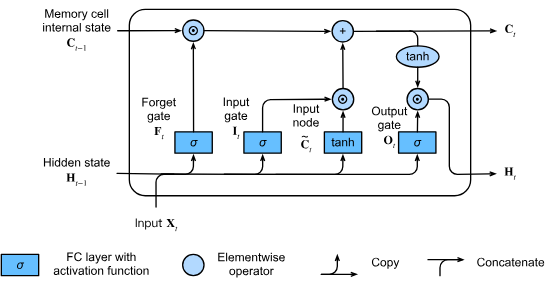


A **single LSTM cell** at time step *t*. It processes the **current input** and the **previous hidden and cell states** to produce updated outputs.

---

## 1. Inputs to the LSTM Cell

* **xₜ** → current input at time *t*
* **hₜ₋₁** → previous hidden state
* **Cₜ₋₁** → previous cell state (top horizontal line)

These inputs are fed into different gates.

---

## 2. Forget Gate (σ)

* Shown using a **sigmoid (σ)** block
* Computes:
  [
  fₜ = σ(W_f [hₜ₋₁, xₜ] + b_f)
  ]
* **Purpose:**
  Decides what information from the previous cell state **should be forgotten or retained**.
* Output values range between **0 and 1**:

  * 0 → forget completely
  * 1 → keep completely

---

## 3. Input Gate (σ) and Candidate Memory (tanh)

There are **two parts** here:

### (a) Input Gate

* Uses sigmoid (σ)
* Decides **what new information to store**
  [
  iₜ = σ(W_i [hₜ₋₁, xₜ] + b_i)
  ]

### (b) Candidate Cell State

* Uses tanh
  [
  \tilde{C}_t = tanh(W_c [hₜ₋₁, xₜ] + b_c)
  ]
* Creates **new candidate values** to add to memory

---

## 4. Cell State Update (Cₜ)

* The old cell state is updated using:
  [
  Cₜ = fₜ \odot Cₜ₋₁ + iₜ \odot \tilde{C}_t
  ]
* **Explanation:**

  * Forget gate removes unnecessary information
  * Input gate adds new relevant information
* This horizontal flow represents **long-term memory**

---

## 5. Output Gate (σ)

* Uses sigmoid (σ)
  [
  oₜ = σ(W_o [hₜ₋₁, xₜ] + b_o)
  ]
* Decides **what part of the cell state to output**

---

## 6. Hidden State Output (hₜ)

* Final output is computed as:
  [
  hₜ = oₜ \odot tanh(Cₜ)
  ]
* This hidden state is:

  * Passed to the **next LSTM cell**
  * Used for **prediction/output**

---

## Key Symbols

* **σ (sigmoid):** Gate control (0 to 1)
* **tanh:** Normalizes values (−1 to +1)
* **⊙ (circle with dot):** Element-wise multiplication
* **+ (plus):** Element-wise addition
* **Top horizontal line:** Cell state (memory flow)



In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler


In [ ]:
!wget https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip


--2026-05-09 18:48:53--  https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.195.207, 172.253.117.207, 142.250.99.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.195.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13568290 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M  71.8MB/s    in 0.2s    

2026-05-09 18:48:54 (71.8 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13568290/13568290]

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  


In [ ]:
df = pd.read_csv("jena_climate_2009_2016.csv")
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [ ]:
data = df['T (degC)'].values.reshape(-1, 1)

In [ ]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)


In [ ]:
def create_sequences(data, time_steps=144):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps, :])   # ALL features
        y.append(data[i+time_steps, 0])     # Temperature only
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled)


In [ ]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (336325, 144, 1)
y_train shape: (336325,)


In [ ]:
model = Sequential([
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 144, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 144, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)


Epoch 1/10
9460/9460 ━━━━━━━━━━━━━━━━━━━━ 147s 15ms/step - loss: 3.4881e-04 - val_loss: 7.5372e-05
Epoch 2/10
9460/9460 ━━━━━━━━━━━━━━━━━━━━ 144s 15ms/step - loss: 4.1178e-05 - val_loss: 2.4359e-05
Epoch 3/10
9460/9460 ━━━━━━━━━━━━━━━━━━━━ 149s 16ms/step - loss: 3.0525e-05 - val_loss: 2.4041e-05
Epoch 4/10
9460/9460 ━━━━━━━━━━━━━━━━━━━━ 144s 15ms/step - loss: 2.7686e-05 - val_loss: 9.9675e-06
Epoch 5/10
9460/9460 ━━━━━━━━━━━━━━━━━━━━ 142s 15ms/step - loss: 2.5985e-05 - val_loss: 1.3459e-05
Epoch 6/10
9460/9460 ━━━━━━━━━━━━━━━━━━━━ 146s 15ms/step - loss: 2.7457e-05 - val_loss: 1.0357e-05
Epoch 7/10
9460/9460 ━━━━━━━━━━━━━━━━━━━━ 142s 15ms/step - loss: 2.3309e-05 - val_loss: 1.0757e-05
Epoch 8/10
9460/9460 ━━━━━━━━━━━━━━━━━━━━ 141s 15ms/step - loss: 2.2455e-05 - val_loss: 2.0324e-05
Epoch 9/10
9460/9460 ━━━━━━━━━━━━━━━━━━━━ 140s 15ms/step - loss: 2.1694e-05 - val_loss: 9.3804e-06
Epoch 10/10
9460/9460 ━━━━━━━━━━━━━━━━━━━━ 141s 15ms/step - loss: 2.1189e-05 - val_loss: 1.4438e-05


2628/2628 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step


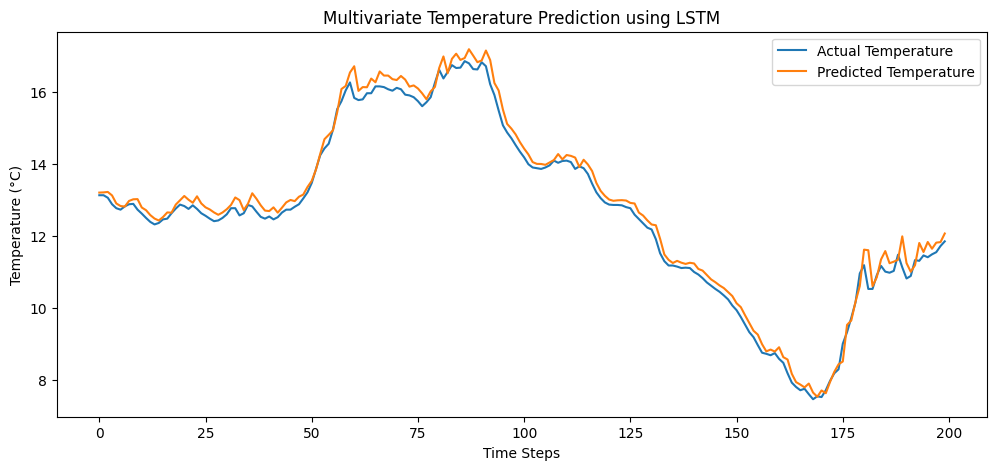

In [ ]:
predictions = model.predict(X_test)
temp_min = scaler.data_min_[0]
temp_max = scaler.data_max_[0]

predicted_temp = predictions * (temp_max - temp_min) + temp_min
actual_temp = y_test * (temp_max - temp_min) + temp_min
plt.figure(figsize=(12, 5))
plt.plot(actual_temp[:200], label="Actual Temperature")
plt.plot(predicted_temp[:200], label="Predicted Temperature")
plt.legend()
plt.title("Multivariate Temperature Prediction using LSTM")
plt.xlabel("Time Steps")
plt.ylabel("Temperature (°C)")
plt.show()


# 📈 Assignment: Multivariate Temperature Prediction

## 🎯 Objective
In the previous exercise, we predicted temperature using only historical temperature data (Univariate). In this assignment, you will build a **Multivariate LSTM** model that uses multiple climate features (Pressure, Humidity, Temperature, etc.) to predict the future temperature.

---

## 🛠️ Part 1: Data Preprocessing
To handle multiple features, we must modify our data pipeline:

1.  **Feature Selection:** Select the following columns from the dataset:
    * `p (mbar)` (Pressure)
    * `T (degC)` (Temperature)
    * `rh (%)` (Relative Humidity)
    * `rho (g/m**3)` (Air Density)
2.  **Normalization:** Use `MinMaxScaler` to scale all selected features between **0** and **1**. Note: You will now have a 2D array of shape `(n_samples, 4)`.
3.  **Windowing:** Create a sliding window function.
    * Use a window of **72 time steps** (12 hours of data if recorded every 10 mins).
    * **Input ($X$):** Should contain all 4 features. Shape: `(samples, 72, 4)`.
    * **Target ($y$):** Should only be the `T (degC)` value of the next time step.

---

## 🧠 Part 2: Model Architecture
Build a more robust LSTM architecture to handle the increased complexity:

* **Layer 1:** `LSTM` with 64 units, `return_sequences=True`.
* **Layer 3:** `Dropout(0.2)` to prevent overfitting.
* **Layer 4:** `LSTM` with 32 units, `return_sequences=False`.
* **Output Layer:** `Dense` layer with 1 unit (the temperature prediction).
* **Compilation:** Use `optimizer='adam'` and `loss='mse'`.

---

## 📉 Part 3: Training & Evaluation
1.  **Split:** Use an **80/20 split** for training and testing.
2.  **Train:** Fit the model for **10 epochs** with a `batch_size` of 64.
3.  **Inverse Scaling:** Remember that your scaler was fit on 4 features. To use `inverse_transform` on the prediction, you must provide a dummy array or save a separate scaler specifically for the Temperature column.
4.  **Metric:** Calculate the **Mean Absolute Error (MAE)** to see how many degrees Celsius the model is off on average.

---

## 📊 Part 4: Visualization & Analysis
* **Plotting:** Create a graph comparing the **Actual Temperature** vs. **Predicted Temperature** for the first 200 steps of the test set.
* **Critical Thinking:** Compare this multivariate model's performance to the univariate model.
    * *Question:* Did adding Pressure and Humidity actually improve the accuracy, or did it just make the model slower to train?

#Sentiment Analysis

We will use the IMDB movie review dataset (positive / negative sentiment).

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense


* `vocab_size = 10000` → only top 10,000 frequent words
* `x_train` → encoded reviews (numbers)
* `y_train` → labels (1 = positive, 0 = negative)






In [ ]:
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Explanation

* Reviews have different lengths
* LSTM needs **fixed-length input**
* Short reviews → padded with zeros
* Long reviews → truncated


In [ ]:
max_len = 200
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)





### What this means:

* `128` → number of **LSTM memory units**
* Internally, TensorFlow creates:

  * Forget gate
  * Input gate
  * Output gate
  * Cell state
* You **do NOT manually code gates** — TensorFlow handles them


* `activation='tanh'` → for cell state
* `recurrent_activation='sigmoid'` → for gates
* `return_sequences=False` → output only final hidden state


In [ ]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),
    LSTM(128),
    Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8088 - loss: 0.4108 - val_accuracy: 0.8654 - val_loss: 0.3228
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.8943 - loss: 0.2678 - val_accuracy: 0.8624 - val_loss: 0.3390
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9309 - loss: 0.1861 - val_accuracy: 0.8414 - val_loss: 0.3494
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9445 - loss: 0.1500 - val_accuracy: 0.8566 - val_loss: 0.3967
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9630 - loss: 0.1075 - val_accuracy: 0.8576 - val_loss: 0.4882


In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)


782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8540 - loss: 0.4876
Test Accuracy: 0.8539999723434448


# 🎭 Assignment: Advanced Sentiment Analysis with LSTMs

## 🎯 Objective
In the previous exercise, you built a basic LSTM for IMDB movie reviews. In this assignment, you will compare three different architectures to determine how model complexity affects the understanding of human sentiment.

---

## 🛠️ Part 1: Data Preparation
Using the IMDB dataset:
1.  **Vocabulary Limit:** Load the data with `num_words=10000`.
2.  **Sequence Padding:** Pad all sequences to a `maxlen` of **250** (slightly longer than the class example).
3.  **Encoding:** Ensure your labels are formatted correctly for binary classification.

---

## 🏗️ Part 2: Architecture Comparison
You must build and train **three** distinct models to see which one handles "sarcasm" and "long-term context" better:

### Model A: The Stacked LSTM
* **Layer 1:** Embedding Layer.
* **Layer 2:** LSTM (64 units) with `return_sequences=True`.
* **Layer 3:** LSTM (32 units) with `return_sequences=False`.
* **Layer 4:** Dense (1 unit, Sigmoid).

### Model B: The Bidirectional LSTM
* **Layer 1:** Embedding Layer.
* **Layer 2:** `Bidirectional(LSTM(64))`.
    * *Note: This allows the model to read the review both forwards and backwards.*
* **Layer 3:** Dense (1 unit, Sigmoid).


## 📉 Part 3: Training & Performance
1.  **Training:** Train each model for **5 epochs** with a `batch_size` of 64.
2.  **Validation:** Use a `validation_split=0.2`.
3.  **Metric Analysis:** Create a table or dataframe to compare the **Test Accuracy** and **Training Time** for all three models.

---

## 🧪 Part 4: The "Review Stress Test"
Test all two models against these two custom reviews and record the probability output:

1.  **Positive:** "This movie was an absolute masterpiece. The acting was superb and the plot kept me on the edge of my seat."
2.  **Sarcastic/Negative:** "I loved waiting two hours for absolutely nothing to happen. Truly a brilliant waste of time."

---

## 📝 Discussion Questions
* Which architecture was the fastest to train?
* Did the **Bidirectional LSTM** perform significantly better on the sarcastic review? Why or why not?
* How does adding a `Conv1D` layer (Model C) before the LSTM affect the model's ability to process long sequences?


# SPAM CLASSIFICATION

We want a model that learns from labeled messages:

| Message                    | Label    |
| -------------------------- | -------- |
| "Win a free iPhone now!"   | Spam (1) |
| "Are we meeting tomorrow?" | Ham (0)  |

This is a **binary classification** problem.






In [ ]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


## Prepare the Dataset

Assume we already have:

* `texts`: list of messages
* `labels`: list of 0s and 1s





In [ ]:
texts = [
    "Win a free prize now",
    "Call me when you arrive",
    "Congratulations you won cash",
    "Let's have lunch tomorrow"
]

labels = [1, 0, 1, 0]





##  Tokenization (Text → Numbers)

Neural networks **cannot read text**, so we convert words to numbers.

###  Create a Tokenizer



In [ ]:

tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)


###  Convert Text to Sequences


Example:

```
"Win a free prize now" → [23, 5, 12, 89, 42]
```


In [ ]:
sequences = tokenizer.texts_to_sequences(texts)



---

##  Padding (Equal Length Sequences)

LSTMs need **equal-length inputs**.

Now every message is length `20`.



In [ ]:

max_length = 20
padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post'
)



##  Build the LSTM Model

This is the **core of spam detection**.

###  Model Architecture

###  What Each Layer Does

| Layer               | Purpose                           |
| ------------------- | --------------------------------- |
| **Embedding**       | Converts word IDs → dense vectors |
| **LSTM**            | Learns word order & context       |
| **Dense (Sigmoid)** | Outputs spam probability          |




In [ ]:
model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=max_length),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
import numpy as np

model.fit(
    padded_sequences,
    np.array(labels),
    epochs=10,
    batch_size=2
)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5000 - loss: 0.6934
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5000 - loss: 0.6996
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5000 - loss: 0.6959
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5000 - loss: 0.6926
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5000 - loss: 0.6924
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5000 - loss: 0.6921
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5000 - loss: 0.6918
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5000 - loss: 0.6914
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5000 - loss: 0.6907
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5000 - loss: 0.6897


In [ ]:
new_text = ["Free entry in a weekly contest"]
seq = tokenizer.texts_to_sequences(new_text)
pad = pad_sequences(seq, maxlen=max_length, padding='post')

prediction = model.predict(pad)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


In [ ]:
if prediction[0][0] > 0.5:
    print("Spam")
else:
    print("Not Spam")

Spam


#Question

## 📈 Dataset for Stock Market Prediction

### **Dataset Source**

**Yahoo Finance – Apple Inc. (AAPL) Stock Data**

### **Time Period**

January 2018 – December 2023 (daily data)

### **Dataset Features**

| Column Name | Description                |
| ----------- | -------------------------- |
| Date        | Trading date               |
| Open        | Opening price of the stock |
| High        | Highest price of the day   |
| Low         | Lowest price of the day    |
| Close       | Closing price of the stock |
| Volume      | Number of shares traded    |

---

##  How to Obtain the Dataset

Download the dataset using:

* **Yahoo Finance website**, or
* **Python (yfinance library)**

```python
import yfinance as yf

data = yf.download("AAPL", start="2018-01-01", end="2024-01-01")
data.to_csv("AAPL_stock.csv")
```

---

##  Task

### **Task 1: Univariate Stock Price Prediction** Using LSTM

* Use **only the `Close` price** column
* Analyze historical trends
* Build a time-series prediction model
* Predict the **next day closing price**



### **Task 2: Multivariate Stock Price Prediction** Using LSTM

* Use **multiple features**:

  * Open
  * High
  * Low
  * Close
  * Volume
* Analyze the relationship between features
* Build a multivariate prediction model
* Predict the **next day closing price**




# 📈 Assignment 2: Gold Price Forecasting using LSTM
**Dataset:** [Daily Gold Price (2015-2025) Time Series](https://www.kaggle.com/datasets/nisargchodavadiya/daily-gold-price-20152021-time-series)  
**Objective:** Build a Deep Learning model to predict the Close Price of 24K Gold (INR/10g) using historical sequential data.

---

## 🛠️ Part 1: Data Preprocessing
Before building the model, the raw data must be cleaned and transformed for Time Series analysis:
1. **Datetime Conversion:** Convert the `Date` column to a datetime object and set it as the index.
2. **Feature Selection:** Filter the dataset to use only the `Price` column.
3. **Normalization:** LSTMs are sensitive to scale. Use `MinMaxScaler` to scale the data between $0$ and $1$.
4. **Windowing:** Create a sliding window dataset.
   * Use a window of **60 days** to predict the price on the **61st day**.
   * Your input $X$ must be shaped as $(samples, 60, 1)$.

## 🧠 Part 2: Model Architecture
Build a stacked LSTM model using `TensorFlow/Keras`. The architecture should include:
* **Layer 1:** LSTM with 50 units, `return_sequences=True`, and `input_shape=(60, 1)`.
* **Layer 2:** LSTM with 50 units, `return_sequences=False`.
* **Layer 3:** Dense layer with 25 units.
* **Output Layer:** Dense layer with 1 unit (the prediction).
* **Optimizer:** `adam`.
* **Loss Function:** `mean_squared_error`.

## 📉 Part 3: Training & Evaluation
1. **Data Split:** Use the first 80% of data for training and the final 20% for testing. *Do not shuffle the data.*
2. **Training:** Fit the model for 20 epochs with a batch size of 32.
3. **Inverse Scaling:** Use `scaler.inverse_transform()` to bring predictions back to the original INR currency scale.
4. **Metrics:** Calculate the **Root Mean Squared Error (RMSE)**:
   $$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

## 📊 Part 4: Visualization
Create a plot using Matplotlib/Plotly that displays:
* The training data.
* The actual test prices.
* The model's predicted prices.

## 🚀 Part 5: The "7-Day Future" Challenge
Using the last 60 days of the dataset (ending Jan 2026), perform **Recursive Multi-step Forecasting** to predict the gold price for the next 7 days out-of-sample.

---
### 📝 Discussion Questions
* How did the model react to the significant price volatility seen in late 2025?
* Would adding the `Volume` or `Chg%` columns as additional features (Multivariate LSTM) improve the RMSE?